# Force Validation

This example validates the uniform-body-force response of the LBM solver in a periodic box. The initial state is
$\rho=1$ and $\mathbf{u}=0$, and the only dynamics comes from a constant prescribed forcing term in the $x$ direction.

## CPU build and run

```bash
cd /home/haotian/lattice_boltzmann_method/Examples/ForceValidation
make -j28 USE_MPI=FALSE USE_OMP=TRUE DEBUG=FALSE
OMP_NUM_THREADS=28 ./main2d.gnu.OMP.ex inputs \
  max_step=1000 stop_time=1000 \
  amr.plot_file=out_validation/plt \
  amr.plot_int=20
```

## Analytical response

For this case the box is periodic and spatially uniform, so the exact flow stays uniform. With the current forcing discretization and `dt=1`, the expected numerical mean velocity at saved time $t>0$ is

$$
\langle u_x \rangle(t) = \frac{(t-1/2)F_x}{\rho_0},
$$

with $F_x = 10^{-6}$ and $\rho_0 = 1$. The saved initial state at $t=0$ is still the prescribed initial condition $u_x=0$, so the relative-error plot below omits that first point.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yt

plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.2

plot_root = Path('out_validation')
plotfiles = sorted(plot_root.glob('plt*'))
assert plotfiles, f'No plotfiles found in {plot_root}'

FORCE_X = 1.0e-6
RHO0 = 1.0


def exact_mean_velocity(time):
    if np.isclose(time, 0.0):
        return 0.0
    return (time - 0.5) * FORCE_X / RHO0


def load_record(plotfile):
    ds = yt.load(str(plotfile))
    ds.force_periodicity()
    cg = ds.covering_grid(level=0, left_edge=ds.domain_left_edge, dims=ds.domain_dimensions)
    ux = np.array(cg[('boxlib', 'ux')])[:, :, 0]
    xlo, ylo = ds.domain_left_edge.d[:2]
    xhi, yhi = ds.domain_right_edge.d[:2]
    return {
        'plotfile': plotfile.name,
        'time': float(ds.current_time),
        'ux': ux,
        'extent': [xlo, xhi, ylo, yhi],
        'ux_mean': float(np.mean(ux)),
        'ux_std': float(np.std(ux)),
    }


results = [load_record(plotfile) for plotfile in plotfiles]
summary = pd.DataFrame({
    'plotfile': [r['plotfile'] for r in results],
    'time': [r['time'] for r in results],
    'ux_mean': [r['ux_mean'] for r in results],
    'ux_std': [r['ux_std'] for r in results],
})
summary['ux_exact'] = summary['time'].map(exact_mean_velocity)
summary['abs_error'] = (summary['ux_mean'] - summary['ux_exact']).abs()
summary['rel_error'] = summary['abs_error'] / summary['ux_exact'].replace(0.0, np.nan)
summary.head(), summary.tail(3)

/home/haotian/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


yt : [INFO     ] 2026-03-28 22:19:11,721 Parameters: current_time              = 0.0


yt : [INFO     ] 2026-03-28 22:19:11,722 Parameters: domain_dimensions         = [64 64  1]


yt : [INFO     ] 2026-03-28 22:19:11,723 Parameters: domain_left_edge          = [0. 0. 0.]


yt : [INFO     ] 2026-03-28 22:19:11,724 Parameters: domain_right_edge         = [64. 64.  1.]


...

yt : [INFO     ] 2026-03-28 22:19:18,665 Parameters: current_time              = 1000.0


yt : [INFO     ] 2026-03-28 22:19:18,665 Parameters: domain_dimensions         = [64 64  1]


yt : [INFO     ] 2026-03-28 22:19:18,666 Parameters: domain_left_edge          = [0. 0. 0.]


yt : [INFO     ] 2026-03-28 22:19:18,667 Parameters: domain_right_edge         = [64. 64.  1.]


(   plotfile  time  ux_mean        ux_std  ux_exact     abs_error  rel_error
 0  plt00000   0.0  0.00000  0.000000e+00  0.000000  0.000000e+00        NaN
 1  plt00020  20.0  0.00002  6.776264e-21  0.000019  5.660377e-08   0.002903
 2  plt00040  40.0  0.00004  0.000000e+00  0.000039  5.660377e-08   0.001433
 3  plt00060  60.0  0.00006  0.000000e+00  0.000059  5.660377e-08   0.000951
 4  plt00080  80.0  0.00008  2.710505e-20  0.000079  5.660377e-08   0.000712,
     plotfile    time  ux_mean        ux_std  ux_exact     abs_error  rel_error
 48  plt00960   960.0  0.00096  2.168404e-19  0.000959  5.660377e-08   0.000059
 49  plt00980   980.0  0.00098  0.000000e+00  0.000979  5.660377e-08   0.000058
 50  plt01000  1000.0  0.00100  2.168404e-19  0.000999  5.660377e-08   0.000057)

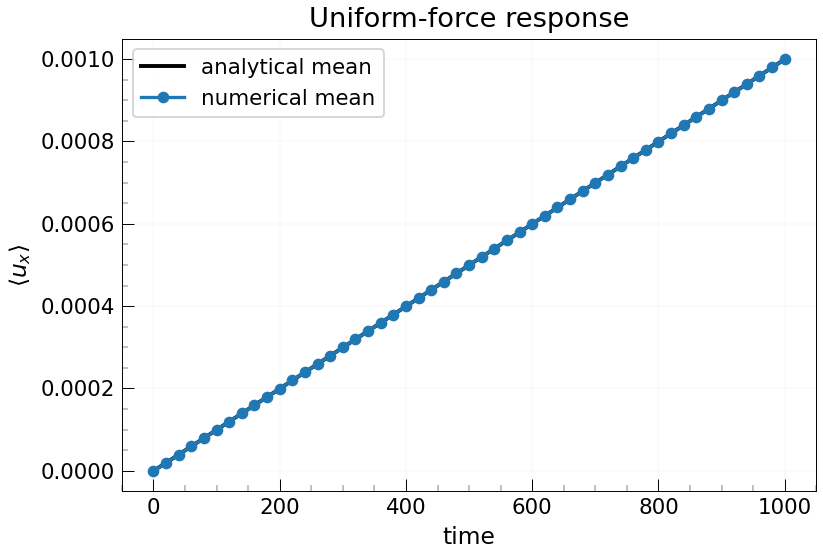

In [2]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.plot(summary['time'], summary['ux_exact'], color='black', linewidth=2, label='analytical mean')
ax.plot(summary['time'], summary['ux_mean'], color='tab:blue', marker='o', linewidth=1.7, label='numerical mean')
ax.set_xlabel('time')
ax.set_ylabel(r'$\langle u_x \rangle$')
ax.set_title('Uniform-force response')
ax.legend()
plt.show()

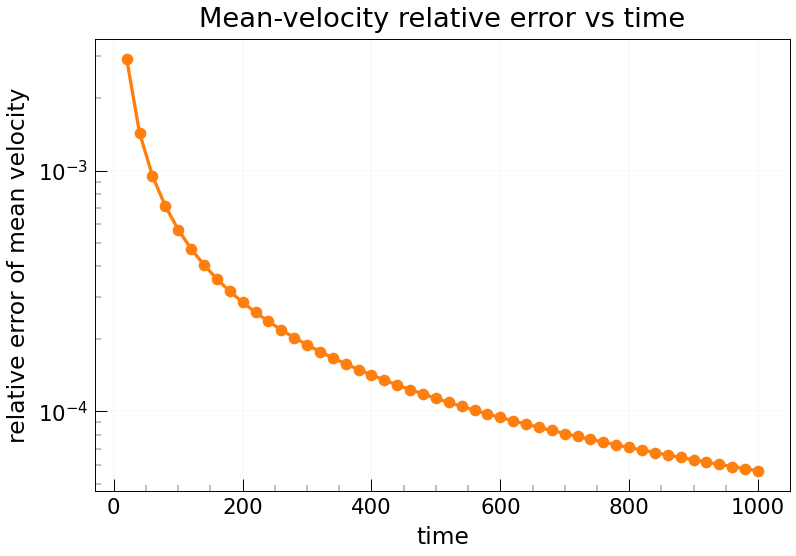

In [3]:
plot_summary = summary[summary['time'] > 0].copy()
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.semilogy(plot_summary['time'], plot_summary['rel_error'], color='tab:orange', marker='o', linewidth=1.7)
ax.set_xlabel('time')
ax.set_ylabel('relative error of mean velocity')
ax.set_title('Mean-velocity relative error vs time')
plt.show()

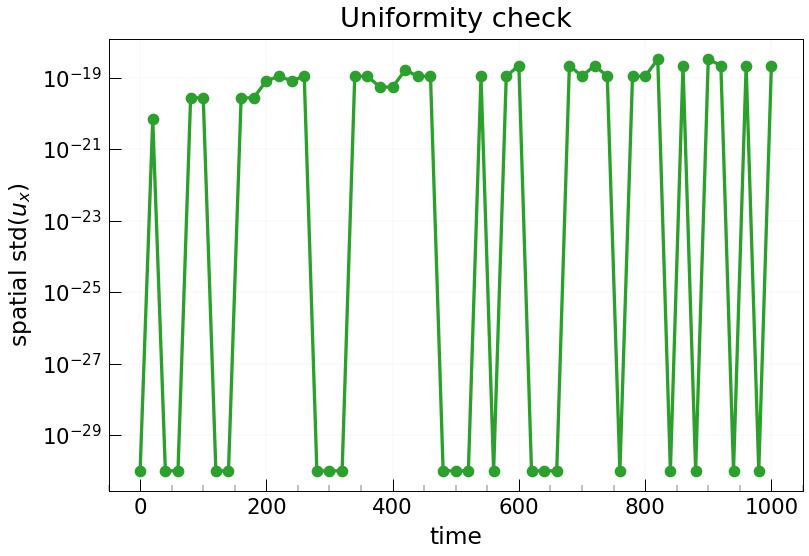

In [4]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.semilogy(summary['time'], summary['ux_std'].replace(0.0, 1.0e-30), color='tab:green', marker='o', linewidth=1.7)
ax.set_xlabel('time')
ax.set_ylabel(r'spatial std$(u_x)$')
ax.set_title('Uniformity check')
plt.show()

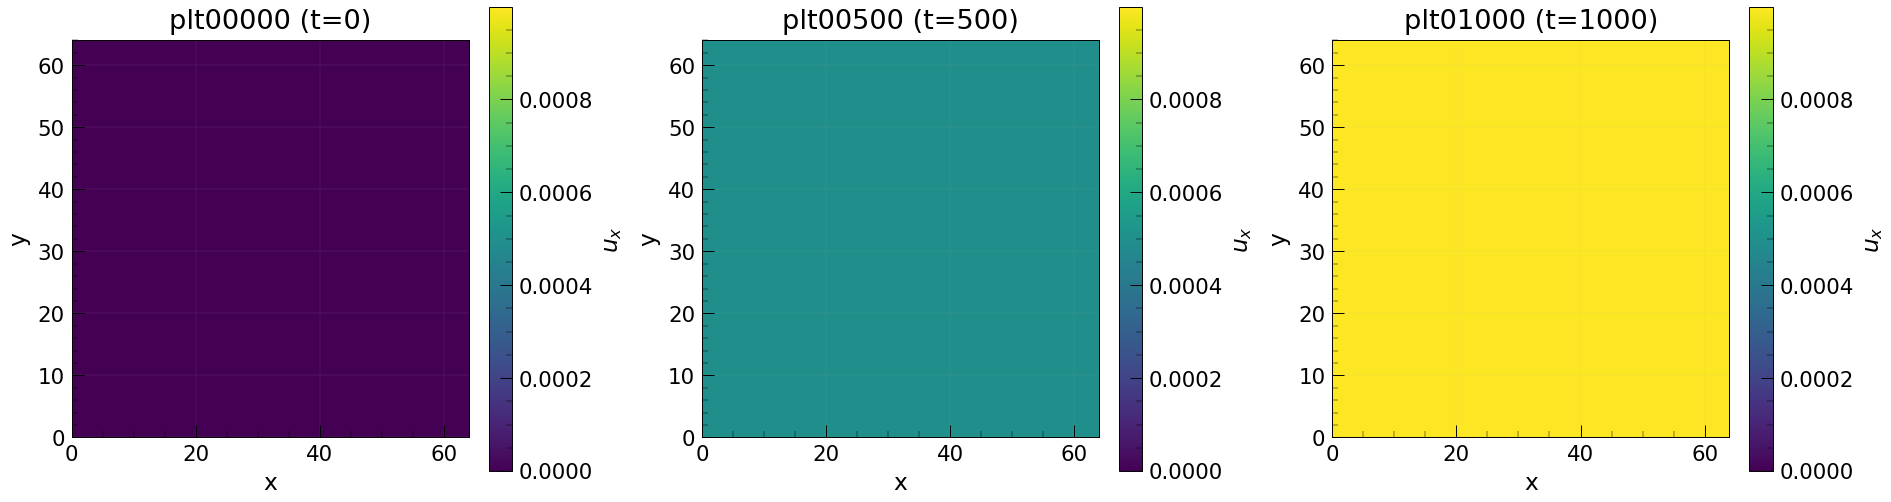

In [5]:
target_times = [0.0, 500.0, 1000.0]
snapshots = []
for target in target_times:
    snapshots.append(min(results, key=lambda r: abs(r['time'] - target)))

vmax = max(float(np.max(r['ux'])) for r in results)
fig, axes = plt.subplots(1, len(snapshots), figsize=(13.5, 4.0), constrained_layout=True)
for ax, r in zip(axes, snapshots):
    im = ax.imshow(
        r['ux'].T,
        extent=r['extent'],
        origin='lower',
        cmap='viridis',
        vmin=0.0,
        vmax=vmax,
    )
    ax.set_title(f"{r['plotfile']} (t={r['time']:.0f})")
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    fig.colorbar(im, ax=ax, shrink=0.85, label=r'$u_x$')
plt.show()